# Aesop AbstractGraph embedding and clustering

This notebook configures and runs the experiment implemented in `experiments/aesop_graph_embeddings_clustering.py`, then displays clustering metrics and representative tales. The module handles corpus loading, graph and embedding checkpoints, vectorization, clustering, and the results manifest.

Graph extraction and text embeddings use hosted APIs and may incur charges. Install with `pip install -e '.[dev,abstractgraph]'`. Generated data is stored under `data/processed/aesop_abstractgraph/`.


In [4]:
from pathlib import Path
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.aesop_graph_embeddings_clustering import run_experiment

SMOKE_TEST = True
SMOKE_LIMIT = 5
EMBED_NODES = True
EMBEDDING_MODEL = "text-embedding-3-small"
RANDOM_SEED = 17
NBITS = 14

experiment = run_experiment(
    ROOT,
    smoke_test=SMOKE_TEST,
    smoke_limit=SMOKE_LIMIT,
    embed_nodes=EMBED_NODES,
    embedding_model=EMBEDDING_MODEL,
    random_seed=RANDOM_SEED,
    nbits=NBITS,
)
stories = experiment["stories"]
metadata = experiment["metadata"]
graphs = experiment["graphs"]
graph_matrix = experiment["graph_matrix"]
text_matrix = experiment["text_matrix"]
graph_features = experiment["graph_features"]
text_features = experiment["text_features"]
cluster_results = experiment["cluster_results"]
metric_rows = experiment["metric_rows"]
agreement_rows = experiment["agreement_rows"]
max_k = experiment["max_k"]
n_tales = len(stories)
print(f"Tales: {n_tales} | graph vectors: {graph_matrix.shape} | text vectors: {text_matrix.shape}")
print(f"Results manifest: {experiment['manifest_path']}")


[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-2a166e484275] segment: 1 -> 1 | 1.6 ms | input_chars=304, chunk_chars=304
[document-2a166e484275 chunk-0] summarize: 1 -> 1 | 1618.3 ms
[document-2a166e484275 chunk-0] normalize: 1 -> 1 | 1390.1 ms
[document-2a166e484275 chunk-0] decompose: 1 -> 5 | 14431.4 ms
[document-2a166e484275 chunk-0] extract: 5 -> 20 | 16211.4 ms
[document-2a166e484275] resolve: 20 -> 0 | 820.6 ms
[document-2a166e484275] integrate: 9 -> 18 | 14.4 ms | nodes=20, edges=18
[document-2a166e484275] total: 1 -> 1 | 34490.4 ms | chunks=1, entities=11, relations=9, nodes=20, edges=18
[document-a8898033e063] segment: 1 -> 1 | 0.1 ms | input_chars=1654, chunk_chars=1654
[document-a8898033e063 chunk-0] summarize: 1 -> 1 | 1404.4 ms
[document-a8898033e063 chunk-0] normalize: 1 -> 1 | 1739.4 ms
[document-a8898033e063 chunk-0] decompose: 1 -> 16 | 6600.7 ms
[document-a8898033e063 chunk-0] extract: 16 -> 31 | 165

## Compare clusterings

Metric scores are inspection aids, not proof of semantic quality. Compare representative tales and boundary cases before drawing conclusions.


In [5]:
try:
    import pandas as pd
    metrics = pd.DataFrame(metric_rows).sort_values(
        ["representation", "silhouette"], ascending=[True, False]
    )
    display(metrics)
except ImportError:
    display(metric_rows)

for row in agreement_rows:
    print(f"k={row['k']}: ARI={row['ari']:.3f}, NMI={row['nmi']:.3f}")


,representation,algorithm,k,silhouette,calinski_harabasz,davies_bouldin
0,AbstractGraph,kmeans,2,0.294392,3.085346,0.418575
3,AbstractGraph,agglomerative,2,0.294392,3.085346,0.418575
1,AbstractGraph,kmeans,3,0.203032,3.591249,0.356720
4,AbstractGraph,agglomerative,3,0.203032,3.591249,0.356720
2,AbstractGraph,kmeans,4,0.136187,6.747775,0.260961
5,AbstractGraph,agglomerative,4,0.136187,6.747775,0.260961
6,Direct text,kmeans,2,0.040882,1.210770,1.518807
9,Direct text,agglomerative,2,0.040882,1.210770,1.518807
7,Direct text,kmeans,3,0.022094,1.153979,1.025289
10,Direct text,agglomerative,3,0.022094,1.153979,1.025289


k=2: ARI=-0.154, NMI=0.202
k=3: ARI=-0.316, NMI=0.395
k=4: ARI=-0.111, NMI=0.792


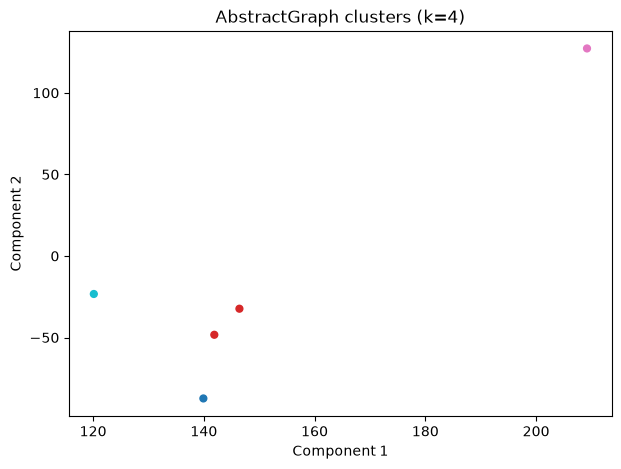

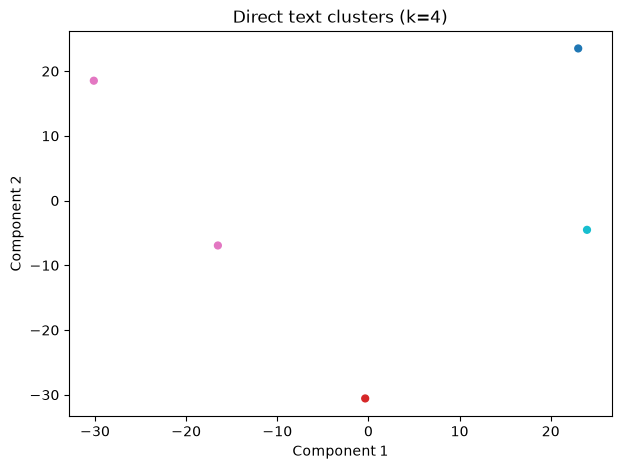

### Cluster 0 (1 tales) — representative: THE SUN AND THE WIND

THE SUN AND THE WIND   [Illustration: The Sun and The Wind]  [Illustrations]  A dispute once arose between the Sun and the Wind, which was the stronger of the two, and they agreed to count this as proof, that whichever soonest made a traveller take off his cloak, should be held the most powerful. The wind began, and blew with all his might and main a blast, cold and fierce as a winter storm; but t
Entity types: [('Action', 11), ('Character', 6), ('Goal', 5), ('Moral', 2)]
Relations: [('performs', 5), ('wants', 3), ('interacts_with', 3), ('causes', 1), ('teaches', 1)]
Argument roles: [('performer', 5), ('action', 5), ('holder', 3), ('goal', 3), ('actor', 3), ('target', 3)]


### Cluster 1 (2 tales) — representative: THE DAW IN BORROWED FEATHERS

THE DAW IN BORROWED FEATHERS   [Illustration: The Daw in Borrowed Feathers]  A conceited jackdaw was vain enough to imagine that he wanted nothing but the coloured plumes to make him as beautiful a bird as the Peacock. Puffed up with this wise conceit, he dressed himself with a quantity of their finest feathers, and in this borrowed garb, leaving his old companions, tried to pass for a peacock; bu
Entity types: [('Animal', 15), ('Action', 7), ('Trait', 3), ('Moral', 2), ('Goal', 1)]
Relations: [('performs', 7), ('has_trait', 3), ('wants', 1), ('interacts_with', 1), ('teaches', 1)]
Argument roles: [('performer', 7), ('action', 7), ('bearer', 3), ('trait', 3), ('holder', 1), ('goal', 1)]


### Cluster 2 (1 tales) — representative: THE FOX AND THE STORK

THE FOX AND THE STORK   [Illustration: The Fox and The Stork]  [Illustrations]  A fox one day invited a Stork to dinner, and being disposed to divert himself at the expense of his guest, provided nothing for dinner but some thin soup in a shallow dish. This the Fox lapped up very readily, while the Stork, unable to gain a mouthful with her long narrow bill, was as hungry at the end of dinner as wh
Entity types: [('Animal', 19), ('Action', 19), ('Trait', 4), ('Object', 2), ('Goal', 1), ('Place', 1)]
Relations: [('performs', 9), ('has_trait', 5), ('located_in', 3), ('causes', 3), ('wants', 1), ('interacts_with', 1)]
Argument roles: [('performer', 9), ('action', 9), ('bearer', 5), ('trait', 5), ('subject', 4), ('place', 3)]


### Cluster 3 (1 tales) — representative: THE DOG IN THE MANGER

THE DOG IN THE MANGER   [Illustration: The Dog in The Manger]  [Illustration]  A dog made his bed in a manger, and lay snarling and growling to keep the horses from their provender. "See," said one of them, "what a miserable cur! who neither can eat corn himself, nor will allow those to eat it who can."
Entity types: [('Animal', 8), ('Action', 6), ('Object', 3), ('Moral', 2), ('Trait', 1)]
Relations: [('performs', 3), ('located_in', 3), ('has_trait', 1), ('interacts_with', 1), ('teaches', 1)]
Argument roles: [('subject', 4), ('performer', 3), ('action', 3), ('place', 3), ('bearer', 1), ('trait', 1)]


In [6]:
selected_k = min(4, n_tales - 1)
for representation, features, reducer in (
    ("AbstractGraph", graph_features, None),
    ("Direct text", text_features, PCA(n_components=2, random_state=RANDOM_SEED)),
):
    coordinates = reducer.fit_transform(features) if reducer is not None else features[:, :2]
    labels = cluster_results[(representation, "kmeans", selected_k)]
    plt.figure(figsize=(7, 5))
    plt.scatter(coordinates[:, 0], coordinates[:, 1], c=labels, cmap="tab10", s=24)
    plt.title(f"{representation} clusters (k={selected_k})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

labels = cluster_results[("AbstractGraph", "kmeans", selected_k)]
for label in sorted(set(labels)):
    members = np.flatnonzero(labels == label)
    distances = pairwise_distances(graph_features[members], metric="euclidean")
    medoid_index = members[int(np.argmin(distances.mean(axis=1)))]
    display(Markdown(
        f"### Cluster {label} ({len(members)} tales) — "
        f"representative: {metadata[medoid_index]['title']}"
    ))
    print(stories[medoid_index][:400].replace("\n", " "))
    graph = graphs[medoid_index]
    entity_types = Counter(data.get("type") for _node, data in graph.nodes(data=True))
    relation_names = Counter(
        data.get("relation") for _node, data in graph.nodes(data=True)
        if data.get("relation")
    )
    argument_roles = Counter(
        data.get("role") for _source, _target, data in graph.edges(data=True)
    )
    print("Entity types:", entity_types.most_common(6))
    print("Relations:", relation_names.most_common(6))
    print("Argument roles:", argument_roles.most_common(6))


Inspect excerpts, recurring entity types, relations, argument roles, nearest tales, and boundary cases. The manifest records the corpus/configuration hashes and results alongside the cached graph artifacts.
